In [ ]:
import sys
sys.path.insert(0, "..")

save_fig = False
FIGURES = "../figures"

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns
from pypalettes import load_cmap

# Load the colormap

cmap_name = "ralts"
cmap_name = "winter"
cmap = load_cmap(cmap_name)

plt.set_cmap(cmap_name)

# seaborn
_ = sns.set_palette(cmap_name)

<Figure size 640x480 with 0 Axes>

1.9748649296709024


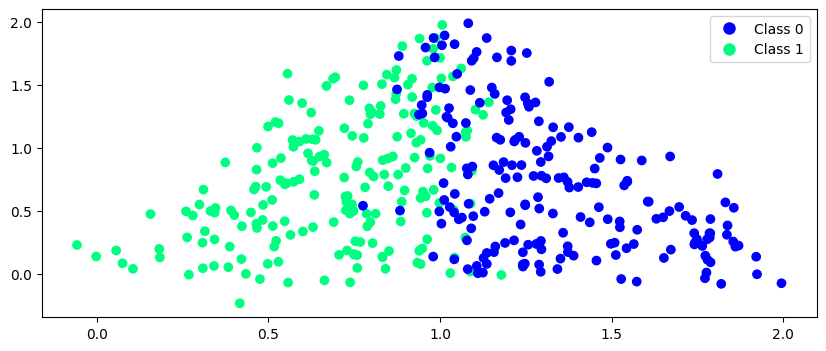

In [40]:
import numpy as np
from archetypes.datasets import make_archetypal_dataset

n_archetypes = 3
generator = np.random.RandomState(42)

archetypes_0 = np.array([[0, 0], [1, 2], [1, 0]])

size_0 = 200
X_0, _, _ = make_archetypal_dataset(archetypes_0, (size_0,), alpha=0.9, noise=0.1, generator=generator)

print(X_0[:, 1].max())
# X_0 = generator.uniform(0, 1, size=(size_0, 2))

y_0 = np.ones(size_0)

archetypes_1 = np.array([[1, 0], [1, 2], [2, 0]])
size_1 = 200
X_1, _, _ = make_archetypal_dataset(archetypes_1, (size_1,), alpha=0.9, noise=0.1, generator=generator)
# X_1 = generator.uniform(0, 1, size=(size_1, 2))

y_1 = np.zeros(size_1)


X = np.concatenate([X_0, X_1])
y = np.concatenate([y_0, y_1])

Z = y - np.mean(y)

Z_0 = Z[y == 1]
Z_1 = Z[y == 0]

Z = Z.reshape(-1, 1)
Z_0 = Z_0.reshape(-1, 1)
Z_1 = Z_1.reshape(-1, 1)

import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.scatter(X[:, 0], X[:, 1], c=y)

# add legend
handles = [
    mpl.lines.Line2D([], [], marker='o', color='w', label='Class 0', markerfacecolor=cmap(0), markersize=10),
    mpl.lines.Line2D([], [], marker='o', color='w', label='Class 1', markerfacecolor=cmap(0.99), markersize=10),
]
ax.legend(handles=handles, loc='upper right')
# save image pdf

if save_fig:
    plt.savefig("dummy_data.pdf")

plt.show()


In [ ]:
from archetypes import AA
from archetypes import FairAA
from src.fair_pca import FairPCA
from src.metrics import mmd_rbf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score
from tqdm import tqdm
import pandas as pd

metrics = None

aa_params = {
    "n_archetypes": 3,
    "init": "furthest_sum",
    "max_iter": 500,
    "n_init": 5,
    "tol": 1e-12,
    "method": "pgd",
}

best_model = None
best_fair_model = None
best_fair_pca_model = None

for i in tqdm(range(10)):
    
    # AA
    model = AA(
        **aa_params,
        random_state=i,
    )

    _ = model.fit(X)

    S_aa = model.transform(X)
    S_0_aa = model.transform(X_0)
    S_1_aa = model.transform(X_1)
    X_aa = S_aa @ model.archetypes_

    # FairAA
    fair_model = FairAA(
        **aa_params,
        fairness_const=1,
        random_state=i,
    )

    _ = fair_model.fit(X, Z=Z)

    S_fair = fair_model.transform(X, Z)
    S_0_fair = fair_model.transform(X_0, Z_0)
    S_1_fair = fair_model.transform(X_1, Z_1)
    X_fair = S_fair @ fair_model.archetypes_


    # FairPCA + AA
    fair_pca = FairPCA(target_dim=2, standardize=False, tradeoff_param=0.5)
    fair_pca.fit(X, y.astype(int))
    X_fair_pca = fair_pca.transform(X)

    model_fair_pca = AA(
        **aa_params,
        random_state=i,
    )
    _ = model_fair_pca.fit(X_fair_pca)
    S_fair_pca = model_fair_pca.transform(X_fair_pca)
    S_0_fair_pca = model_fair_pca.transform(fair_pca.transform(X_0))
    S_1_fair_pca = model_fair_pca.transform(fair_pca.transform(X_1))
    X_fair_pca_aa = fair_pca.inverse_transform(S_fair_pca @ model_fair_pca.archetypes_)


    # Explained Variance
    ev_aa = explained_variance_score(X, X_aa)
    ev_fair = explained_variance_score(X, X_fair)
    ev_fair_pca = explained_variance_score(X, X_fair_pca_aa)

    ev = pd.DataFrame({
        "metric": "explained_variance",
        "value": [ev_aa, ev_fair, ev_fair_pca],
        "method": ["AA", "FairAA", "FairPCA+AA"],
        "run": i,
    })
    
    # Maximum Mean Discrepancy (MMD)
    mmd_aa = mmd_rbf(S_0_aa, S_1_aa)
    mmd_fair = mmd_rbf(S_0_fair, S_1_fair)
    mmd_fair_pca = mmd_rbf(S_0_fair_pca, S_1_fair_pca)
    
    mmd = pd.DataFrame({
        "metric": "mmd",
        "value": [mmd_aa, mmd_fair, mmd_fair_pca],
        "method": ["AA", "FairAA", "FairPCA+AA"],
        "run": i,
    })

    # Linear separability
    S_aa_train, S_aa_test, y_train, y_test = train_test_split(S_aa, y, test_size=0.3, random_state=i)
    S_fair_train, S_fair_test, y_train, y_test = train_test_split(S_fair, y, test_size=0.3, random_state=i)
    S_fair_pca_train, S_fair_pca_test, y_train, y_test = train_test_split(S_fair_pca, y, test_size=0.3, random_state=i)
    
    clf_aa = LogisticRegression(random_state=i)
    clf_fair = LogisticRegression(random_state=i)
    clf_fair_pca = LogisticRegression(random_state=i)

    clf_aa.fit(S_aa_train, y_train)
    clf_fair.fit(S_fair_train, y_train)
    clf_fair_pca.fit(S_fair_pca_train, y_train)

    ls_aa = clf_aa.score(S_aa_test, y_test)
    ls_fair = clf_fair.score(S_fair_test, y_test)
    ls_fair_pca = clf_fair_pca.score(S_fair_pca_test, y_test)

    ls = pd.DataFrame({
        "metric": "linear_separability",
        "value": [ls_aa, ls_fair, ls_fair_pca],
        "method": ["AA", "FairAA", "FairPCA+AA"],
        "run": i,
    })

    # Check if best model
    if best_model is None or best_model.loss_[-1] > model.loss_[-1]:
        best_model = model
    
    if best_fair_model is None or best_fair_model.loss_[-1] > fair_model.loss_[-1]:
        best_fair_model = fair_model

    if best_fair_pca_model is None or best_fair_pca_model.loss_[-1] > model_fair_pca.loss_[-1]:
        best_fair_pca_model = model_fair_pca

    # Concatenate metrics
    metrics = pd.concat([metrics, ev, mmd, ls])

/Users/aalcacer/Projects/fair-archetypes/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/aalcacer/Projects/fair-archetypes/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/aalcacer/Projects/fair-archetypes/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


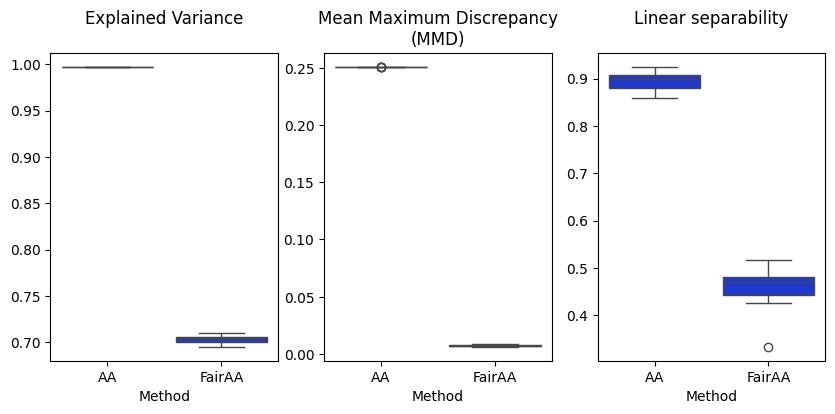

In [17]:
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# plot variance explained
sns.boxplot(data=metrics[metrics["metric"] == "explained_variance"], x="method", y="value", ax=ax[0])
ax[0].set_ylabel("")
ax[0]. set_xlabel("Method")
ax[0].set_title("Explained Variance\n")

# plot MMD
sns.boxplot(data=metrics[metrics["metric"] == "mmd"], x="method", y="value", ax=ax[1])
ax[1].set_ylabel("")
ax[1]. set_xlabel("Method")
ax[1].set_title("Mean Maximum Discrepancy\n(MMD)")

# plot linear separability
sns.boxplot(data=metrics[metrics["metric"] == "linear_separability"], x="method", y="value", ax=ax[2])
ax[2].set_ylabel("")
ax[2]. set_xlabel("Method")
ax[2].set_title("Linear separability\n")

if save_fig:
    plt.savefig("dummy_metrics.pdf")

plt.show()

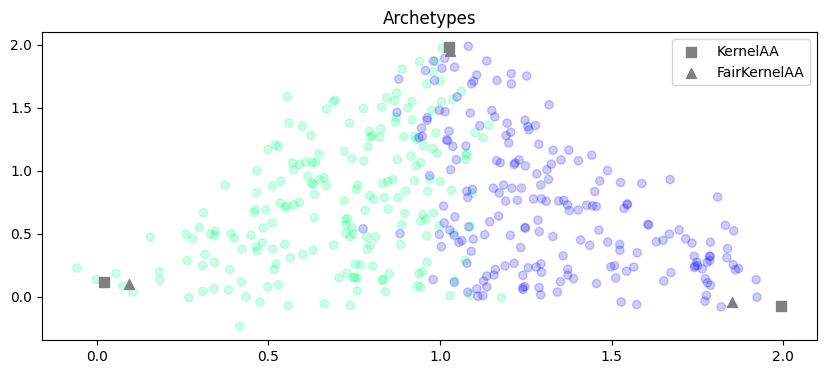

In [18]:
# plot archetypes

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2)

ax.scatter(best_model.archetypes_[:, 0], best_model.archetypes_[:, 1], marker="s", s=50, color="gray", label="KernelAA")

ax.scatter(best_fair_model.archetypes_[:, 0], best_fair_model.archetypes_[:, 1], marker="^", s=50, color="gray", label="FairKernelAA")

ax.set_title("Archetypes")

ax.legend()

if save_fig:
    plt.savefig("dummy_archetypes.pdf")

plt.show()

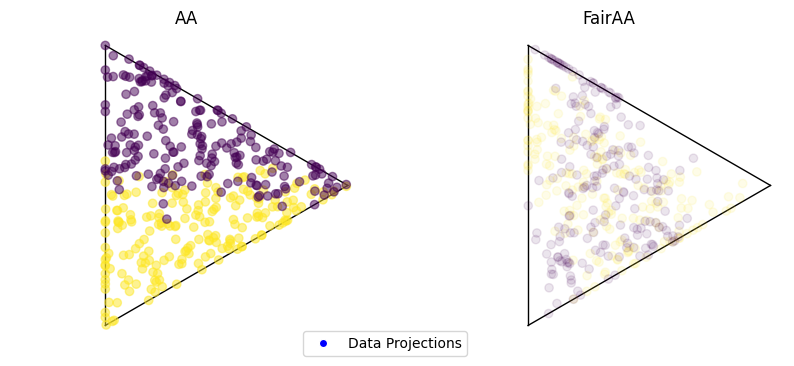

In [31]:
from archetypes.visualization import simplex


fig, ax = plt.subplots(1, 2, figsize=(10, 4))

simplex(
    best_model.coefficients_,
    ax=ax[0],
    color=y,
    alpha=0.5,
    show_vertices=False,
    )

# set title
ax[0].set_title("AA")

simplex(
    best_fair_model.coefficients_,
    ax=ax[1],
    color=y,
    alpha=0.1,
    show_vertices=False,
)

# set title
ax[1].set_title("FairAA")


# create custom legend for the figure

# Add a red point for archetypes, and a yellow point for data projections
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap.colors[0],
           markersize=mpl.rcParams['lines.markersize'], label='Data Projections'),
]

fig.legend(handles=legend_elements,  loc="center", bbox_to_anchor=(0.5, 0.1), ncol=2)

if save_fig:
    plt.savefig("dummy_simplex.pdf")

plt.show()

